# Data Analysis for Maximizing revenue for Cab drivers

## Problem Statement:
In the rapidly growing taxi service industry, boosting driver income is key to maintaining long-term growth and satisfaction. This project seeks to understand whether the type of payment used by passengers influences the total fare amount. By analyzing the relationship between payment type and fare amount, we hope to find useful insights that can help improve revenue for taxi drivers. 

## Objective:
This project aims to check if the total fare of a taxi ride depends on payment method — by cash or credit card. We will use Python to do some basic statistics and hypothesis testing to see if there's a noticeable difference. The goal is to help taxi drivers understand if one payment method brings in more money than the other.


## Research Question:
Is there a connection between the total fare amount and the payment method used? Can we encourage customers to choose payment options that help drivers earn more, without affecting the overall customer experience?

# Import Libraries 

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [2]:
taxi_data = pd.read_csv("https://www.kaggle.com/datasets/microize/newyork-yellow-taxi-trip-data-2020-2019")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 9, saw 2


Got error while importing data. Used kaggle API token for importing data directly from kaggle

In [3]:
taxi_data = pd.read_parquet("nyc_taxi_data_2024/yellow_tripdata_2024_combined.parquet")
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [4]:
taxi_data.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
26388174,2,2024-08-31 23:22:27,2024-08-31 23:52:10,NaN,10.90,NaN,None,56,35,0,41.25,0.0,0.5,0.0,0.0,1.0,42.75,NaN,NaN
26388175,2,2024-08-31 23:46:00,2024-09-01 00:10:00,NaN,6.42,NaN,None,148,236,0,26.70,0.0,0.5,0.0,0.0,1.0,30.70,NaN,NaN
26388176,2,2024-08-31 23:41:20,2024-08-31 23:56:24,NaN,1.89,NaN,None,68,100,0,18.90,0.0,0.5,0.0,0.0,1.0,22.90,NaN,NaN
26388177,2,2024-08-31 23:20:50,2024-08-31 23:35:33,NaN,6.02,NaN,None,231,141,0,29.13,0.0,0.5,0.0,0.0,1.0,33.13,NaN,NaN
26388178,1,2024-08-31 23:24:04,2024-08-31 23:36:45,NaN,1.90,NaN,None,114,224,0,13.54,0.0,0.5,0.0,0.0,1.0,17.54,NaN,NaN


# Exploratory Data Analysis

In [5]:
# Rows & columns of the dataset
taxi_data.shape

(26388179, 19)

In [6]:
#Gives datatype of each column
taxi_data.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

Already pickup and dropoff columns are in datetime format and not in object format. Hence no need to convert it.

In [7]:
# To calculate duration subtract dropoff and pickup time
taxi_data['Duration']= taxi_data['tpep_dropoff_datetime']-taxi_data['tpep_pickup_datetime']
taxi_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,Duration
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.70,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,0 days 00:19:48
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.00,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,0 days 00:06:36
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.30,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,0 days 00:17:55
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.00,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,0 days 00:08:18
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.90,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,0 days 00:06:06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26388174,2,2024-08-31 23:22:27,2024-08-31 23:52:10,NaN,10.90,NaN,None,56,35,0,41.25,0.0,0.5,0.00,0.0,1.0,42.75,NaN,NaN,0 days 00:29:43
26388175,2,2024-08-31 23:46:00,2024-09-01 00:10:00,NaN,6.42,NaN,None,148,236,0,26.70,0.0,0.5,0.00,0.0,1.0,30.70,NaN,NaN,0 days 00:24:00
26388176,2,2024-08-31 23:41:20,2024-08-31 23:56:24,NaN,1.89,NaN,None,68,100,0,18.90,0.0,0.5,0.00,0.0,1.0,22.90,NaN,NaN,0 days 00:15:04
26388177,2,2024-08-31 23:20:50,2024-08-31 23:35:33,NaN,6.02,NaN,None,231,141,0,29.13,0.0,0.5,0.00,0.0,1.0,33.13,NaN,NaN,0 days 00:14:43


But duration is in days format which is not useful. Hence we will convert it into minutes.

In [8]:
# Converting duration into minutes
taxi_data['Duration']=taxi_data['Duration'].dt.total_seconds()/60
taxi_data

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,Duration
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.70,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,19.800000
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.00,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6.600000
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.30,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,17.916667
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.00,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,8.300000
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.90,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,6.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26388174,2,2024-08-31 23:22:27,2024-08-31 23:52:10,NaN,10.90,NaN,None,56,35,0,41.25,0.0,0.5,0.00,0.0,1.0,42.75,NaN,NaN,29.716667
26388175,2,2024-08-31 23:46:00,2024-09-01 00:10:00,NaN,6.42,NaN,None,148,236,0,26.70,0.0,0.5,0.00,0.0,1.0,30.70,NaN,NaN,24.000000
26388176,2,2024-08-31 23:41:20,2024-08-31 23:56:24,NaN,1.89,NaN,None,68,100,0,18.90,0.0,0.5,0.00,0.0,1.0,22.90,NaN,NaN,15.066667
26388177,2,2024-08-31 23:20:50,2024-08-31 23:35:33,NaN,6.02,NaN,None,231,141,0,29.13,0.0,0.5,0.00,0.0,1.0,33.13,NaN,NaN,14.716667


In [9]:
taxi_data.drop(['VendorID','tpep_pickup_datetime','tpep_dropoff_datetime',
                'RatecodeID','store_and_fwd_flag','PULocationID','DOLocationID','extra',
                'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge'
                ,'total_amount','congestion_surcharge'],
               axis = 1, inplace = True)

In [10]:
# Filtered data required for analysis
taxi_data.head()

,passenger_count,trip_distance,payment_type,fare_amount,Airport_fee,Duration
0,1.0,1.72,2,17.7,0.0,19.800000
1,1.0,1.80,1,10.0,0.0,6.600000
2,1.0,4.70,1,23.3,0.0,17.916667
3,1.0,1.40,1,10.0,0.0,8.300000
4,1.0,0.80,1,7.9,0.0,6.100000


In [11]:
taxi_data.isnull().sum()

passenger_count    2513641
trip_distance            0
payment_type             0
fare_amount              0
Airport_fee        2513641
Duration                 0
dtype: int64

In [12]:
#Checking % contribution of columns having missing values
(2513641/len(taxi_data))*100

9.525632670598453

In [13]:
taxi_data['passenger_count'].value_counts()

passenger_count
1.0    18413783
2.0     3454930
3.0      827756
4.0      515685
0.0      276471
5.0      230232
6.0      155484
8.0         142
7.0          34
9.0          21
Name: count, dtype: int64

We can see that 1 is most common value. hence we can replace missing values with mode.

In [14]:
# inplace=True updates the column directly in the original DataFrame
# mode()[0]-->If tie happens between two modes, then 1st mode is selected
taxi_data['passenger_count'].fillna(taxi_data['passenger_count'].mode()[0],inplace=True)

In [15]:
#Usually this column is only filled when the trip involves the airport. If your analysis is not focused on airport trips, you can safely drop it.
# axis= 1--> perform operation on columns
taxi_data.drop('Airport_fee',axis=1,inplace=True)

In [16]:
taxi_data.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
Duration           0
dtype: int64

In [17]:
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1.0,1.72,2,17.70,19.800000
1,1.0,1.80,1,10.00,6.600000
2,1.0,4.70,1,23.30,17.916667
3,1.0,1.40,1,10.00,8.300000
4,1.0,0.80,1,7.90,6.100000
...,...,...,...,...,...
26388174,1.0,10.90,0,41.25,29.716667
26388175,1.0,6.42,0,26.70,24.000000
26388176,1.0,1.89,0,18.90,15.066667
26388177,1.0,6.02,0,29.13,14.716667


In [18]:
taxi_data['passenger_count']=taxi_data['passenger_count'].astype('int64')

In [19]:
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,1.72,2,17.70,19.800000
1,1,1.80,1,10.00,6.600000
2,1,4.70,1,23.30,17.916667
3,1,1.40,1,10.00,8.300000
4,1,0.80,1,7.90,6.100000
...,...,...,...,...,...
26388174,1,10.90,0,41.25,29.716667
26388175,1,6.42,0,26.70,24.000000
26388176,1,1.89,0,18.90,15.066667
26388177,1,6.02,0,29.13,14.716667


In [20]:
#returns a Boolean Series (True/False for each row):
#True means the row is a duplicate (an exact match of an earlier row).
taxi_data[taxi_data.duplicated()]

,passenger_count,trip_distance,payment_type,fare_amount,Duration
1028,2,0.70,1,6.50,4.816667
2594,2,0.75,1,5.80,3.250000
2795,3,0.81,1,8.60,7.983333
2996,1,2.06,1,12.80,11.033333
3386,1,1.52,1,9.30,6.633333
...,...,...,...,...,...
26387875,1,2.40,0,13.50,11.666667
26387919,1,3.15,0,15.44,16.000000
26387928,1,0.30,0,6.47,3.900000
26388031,1,1.20,0,7.90,6.033333


In [21]:
taxi_data.duplicated().sum()

14835130

In [22]:
taxi_data.drop_duplicates(inplace=True)

In [23]:
taxi_data.shape

(11553049, 5)

In [24]:
# value_counts() → counts how many times each unique value appears in the passenger_count column.
# normalize=True → shows the percentage (proportion) instead of raw counts.
taxi_data['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.710526
2    0.158560
3    0.052378
4    0.036534
5    0.017082
0    0.012941
6    0.011963
8    0.000012
7    0.000003
9    0.000002
Name: proportion, dtype: float64

0 passengers not possible hence remove them.
We will also remove 7,8,9 and may be 6 since we dont expect these many passengers and 
also they are not contributing that much.

In [25]:
taxi_data['payment_type'].value_counts()

payment_type
1    6613974
0    2398569
2    2027765
4     381704
3     131034
5          3
Name: count, dtype: int64

In [26]:
# Filtering payment type for 0,1 & 2
taxi_data=taxi_data[taxi_data['payment_type']<3]
#Filtering passenger count from 1 to 5
taxi_data=taxi_data[(taxi_data['passenger_count']>0) & (taxi_data['passenger_count']<6)] 

In [27]:
taxi_data.shape

(10759811, 5)

In [28]:
taxi_data['payment_type'].replace([0,1,2],['Flex Fare trip','Card','Cash'],inplace=True)

In [29]:
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,1.72,Cash,17.70,19.800000
1,1,1.80,Card,10.00,6.600000
2,1,4.70,Card,23.30,17.916667
3,1,1.40,Card,10.00,8.300000
4,1,0.80,Card,7.90,6.100000
...,...,...,...,...,...
26388174,1,10.90,Flex Fare trip,41.25,29.716667
26388175,1,6.42,Flex Fare trip,26.70,24.000000
26388176,1,1.89,Flex Fare trip,18.90,15.066667
26388177,1,6.02,Flex Fare trip,29.13,14.716667


In [30]:
taxi_data.describe()

,passenger_count,trip_distance,fare_amount,Duration
count,1.075981e+07,1.075981e+07,1.075981e+07,1.075981e+07
mean,1.454854e+00,9.170019e+00,2.921415e+01,2.560671e+01
std,8.932139e-01,5.752940e+02,2.360432e+01,5.132749e+01
min,1.000000e+00,0.000000e+00,-2.164600e+03,-5.206667e+01
25%,1.000000e+00,1.800000e+00,1.490000e+01,1.298333e+01
50%,1.000000e+00,3.460000e+00,2.260000e+01,2.020000e+01
75%,2.000000e+00,7.900000e+00,3.730000e+01,3.031667e+01
max,5.000000e+00,3.270252e+05,1.289840e+04,9.767517e+03


Trip distance, fare amount & duration cant be negative. Hence the values are wrong. We need to remove them.
Max value is very much higher as compared to 50th percentiles, hence may be outliers are present in the data.

In [31]:
# Filtering out positive values only
taxi_data=taxi_data[taxi_data['trip_distance']>0]
taxi_data=taxi_data[taxi_data['fare_amount']>0]
taxi_data=taxi_data[taxi_data['Duration']>0]

In [32]:
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,1.72,Cash,17.70,19.800000
1,1,1.80,Card,10.00,6.600000
2,1,4.70,Card,23.30,17.916667
3,1,1.40,Card,10.00,8.300000
4,1,0.80,Card,7.90,6.100000
...,...,...,...,...,...
26388174,1,10.90,Flex Fare trip,41.25,29.716667
26388175,1,6.42,Flex Fare trip,26.70,24.000000
26388176,1,1.89,Flex Fare trip,18.90,15.066667
26388177,1,6.02,Flex Fare trip,29.13,14.716667


In [33]:
taxi_data.describe()

,passenger_count,trip_distance,fare_amount,Duration
count,1.040040e+07,1.040040e+07,1.040040e+07,1.040040e+07
mean,1.463722e+00,9.300589e+00,2.982013e+01,2.590305e+01
std,9.000810e-01,5.722854e+02,2.219074e+01,5.117095e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.900000e+00,1.490000e+01,1.321667e+01
50%,1.000000e+00,3.590000e+00,2.330000e+01,2.045000e+01
75%,2.000000e+00,8.140000e+00,3.800000e+01,3.058333e+01
max,5.000000e+00,3.270252e+05,2.221300e+03,9.767517e+03


Now minimum data is around 1 and negative values has been removed.

(array([1.0394141e+07, 5.8320000e+03, 3.4900000e+02, 5.0000000e+01,
        1.9000000e+01, 3.0000000e+00, 2.0000000e+00, 3.0000000e+00,
        0.0000000e+00, 2.0000000e+00]),
 array([1.000000e-02, 2.221390e+02, 4.442680e+02, 6.663970e+02,
        8.885260e+02, 1.110655e+03, 1.332784e+03, 1.554913e+03,
        1.777042e+03, 1.999171e+03, 2.221300e+03]),
 <BarContainer object of 10 artists>)

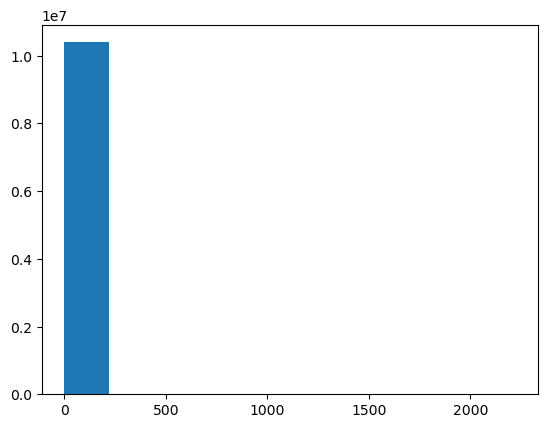

In [34]:
plt.hist(taxi_data['fare_amount'])

spread is till 2000, hence outliers are present. Now we will check it again using boxplot

{'whiskers': [<matplotlib.lines.Line2D at 0x20d0ca24260>,
 'caps': [<matplotlib.lines.Line2D at 0x20d0ca24830>,
 'boxes': [<matplotlib.lines.Line2D at 0x20d0c9ebfe0>],
 'medians': [<matplotlib.lines.Line2D at 0x20d0ca24c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x20d0ca24f20>],
 'means': []}

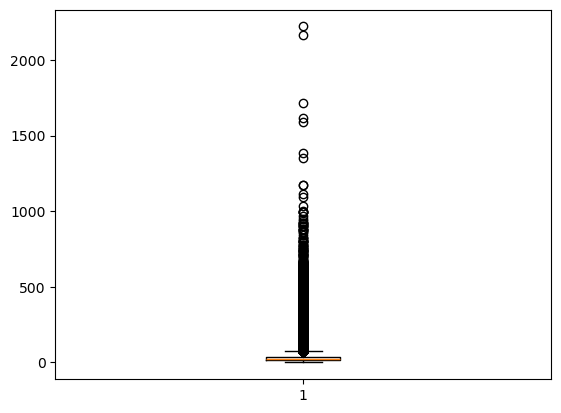

In [35]:
plt.boxplot(taxi_data['fare_amount'])

Can see more outliers than data. Hence need to remove them

Now out of 2 methods of removing outliers, z score method is not useful here. because we can see that data is not that much normally distributed.
1) Mean is not close to median value
2) Distance between mean-min & mean-max is not equal approxiamately.
3) Min and max value difference is more hence outliers present

Hence we will use IQR method.

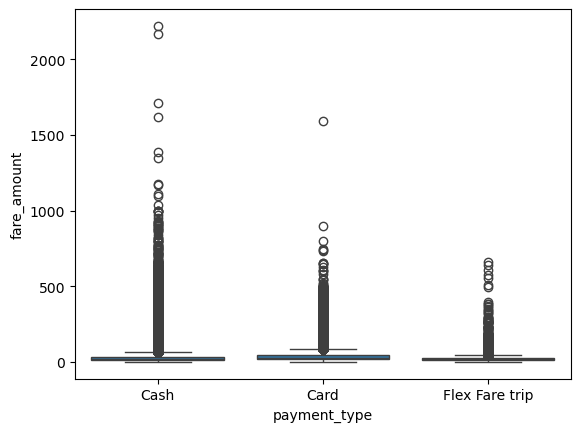

In [36]:
sns.boxplot(data=taxi_data,y='fare_amount', x='payment_type')
plt.show()

In [37]:
# removing outliers using interquartile range for the numerical variables
for col in ['trip_distance','fare_amount','Duration']:
    Q1=taxi_data[col].quantile(0.25)
    Q3=taxi_data[col].quantile(0.75)
    IQR=Q3-Q1
    # Define lower and upper bounds for outliers
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    # Filter out outliers
    taxi_data=taxi_data[(taxi_data[col] >= lower_bound) & (taxi_data[col] <= upper_bound)]

In [38]:
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,1.72,Cash,17.70,19.800000
1,1,1.80,Card,10.00,6.600000
2,1,4.70,Card,23.30,17.916667
3,1,1.40,Card,10.00,8.300000
4,1,0.80,Card,7.90,6.100000
...,...,...,...,...,...
26388174,1,10.90,Flex Fare trip,41.25,29.716667
26388175,1,6.42,Flex Fare trip,26.70,24.000000
26388176,1,1.89,Flex Fare trip,18.90,15.066667
26388177,1,6.02,Flex Fare trip,29.13,14.716667


To check impact of fare amount and trip distance on choice of payment method by customers,we will plot histogram and check distribution

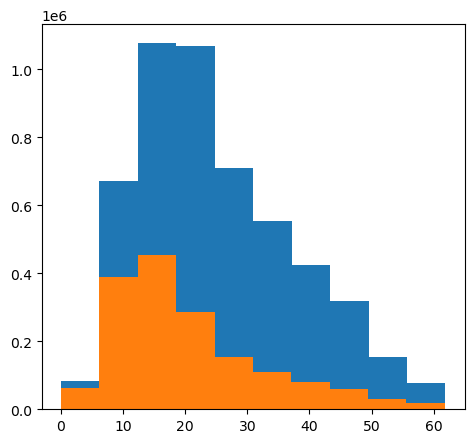

In [39]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['fare_amount'],histtype='barstacked')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['fare_amount'],histtype='barstacked')
plt.show()

We can see the distribution but it is not visually appealing. Hence we will make some changes

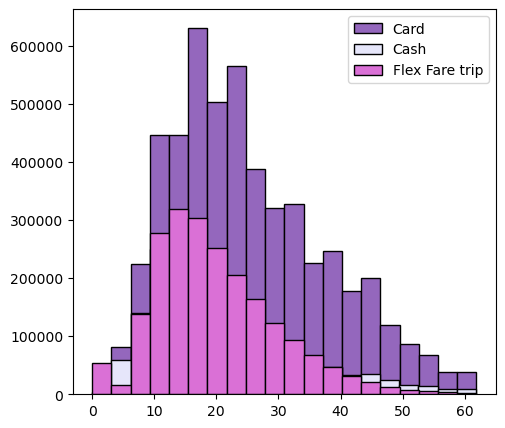

In [40]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['fare_amount'],histtype='barstacked', bins=20, edgecolor='k', color='#9467bd', label='Card')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['fare_amount'],histtype='barstacked', bins=20, edgecolor='k', color='#e6e6fa', label='Cash')
plt.hist(taxi_data[taxi_data['payment_type']=='Flex Fare trip']['fare_amount'],histtype='barstacked', bins=20, edgecolor='k', color='#da70d6', label='Flex Fare trip')
plt.legend()
plt.show()

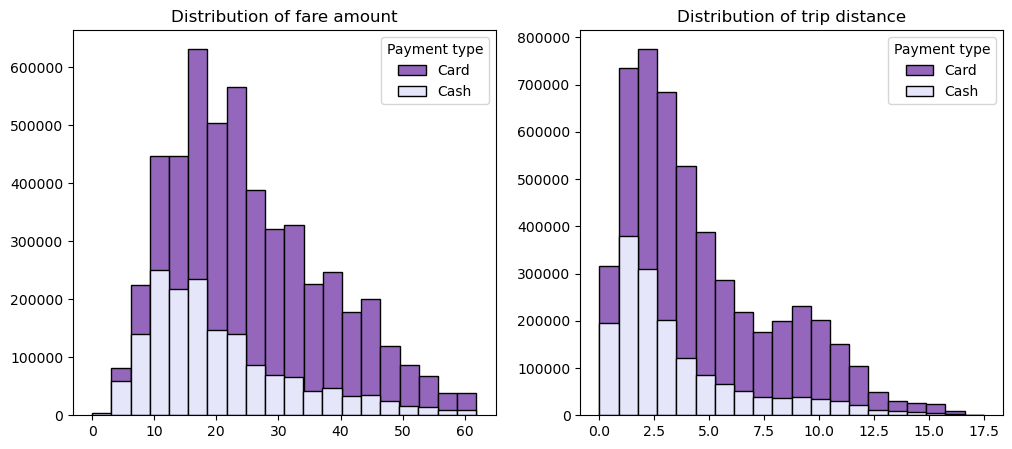

In [41]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of fare amount')
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['fare_amount'],histtype='barstacked', bins=20, edgecolor='k', color='#9467bd', label='Card')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['fare_amount'],histtype='barstacked', bins=20, edgecolor='k', color='#e6e6fa', label='Cash')
plt.legend(title='Payment type')

plt.subplot(1,2,2)
plt.title('Distribution of trip distance')
plt.hist(taxi_data[taxi_data['payment_type']=='Card']['trip_distance'],histtype='barstacked', bins=20, edgecolor='k', color='#9467bd', label='Card')
plt.hist(taxi_data[taxi_data['payment_type']=='Cash']['trip_distance'],histtype='barstacked', bins=20, edgecolor='k', color='#e6e6fa', label='Cash')
plt.legend(title='Payment type')
plt.show()


Distribution of fare amount is went till 50 and trip distance beyond 10

In [42]:
taxi_data.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount            trip_distance          
                      mean        std          mean       std
payment_type                                                 
Card             25.239431  12.426530      4.650931  3.401403
Cash             20.527806  11.821543      3.543306  3.112898
Flex Fare trip   19.958922   9.841709      3.183038  2.355663

Above values shows that mean and standard deviation values are higher for Card than cash and flex fare trip. This indicates that when fare amount and trip distance is increasing, people are preferring card payment over other payment methods. Histograms is also showing the same.

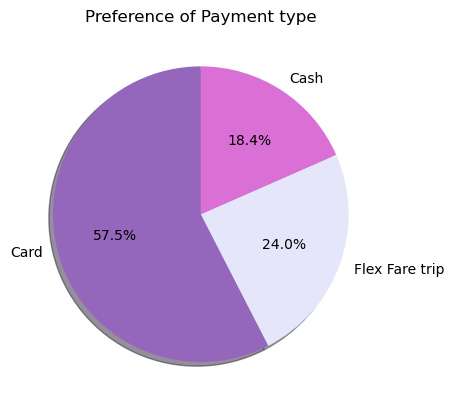

In [43]:
plt.title('Preference of Payment type')
plt.pie(taxi_data['payment_type'].value_counts(normalize=True), labels=taxi_data['payment_type'].value_counts().index,
       startangle=90,shadow=True,autopct='%1.1f%%', colors=['#9467bd','#e6e6fa','#da70d6'])
plt.show()

We can observe that 56.5% passengers pay through card. Now we will see impact of passenger count on payment type.

In [44]:
# calculating the total passenger count distribution based on the different payment type
passenger_count=taxi_data.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count

passenger_count
payment_type   passenger_count                 
Card           1                        3310008
               2                        1057608
               3                         378754
               4                         242058
               5                         147816
Cash           1                        1054189
               2                         343311
               3                         118398
               4                          93921
               5                          33636
Flex Fare trip 1                        2145846

In [46]:
#We will remove flex fare trip
taxi_data = taxi_data[taxi_data['payment_type'].isin(['Cash', 'Card'])]
taxi_data

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,1.72,Cash,17.7,19.800000
1,1,1.80,Card,10.0,6.600000
2,1,4.70,Card,23.3,17.916667
3,1,1.40,Card,10.0,8.300000
4,1,0.80,Card,7.9,6.100000
...,...,...,...,...,...
26129483,2,3.26,Card,17.7,13.516667
26129487,1,4.36,Card,31.0,35.633333
26129492,3,1.59,Card,11.4,11.166667
26129500,1,9.30,Card,38.7,26.066667


### Why 'Flex Fare trip' is Removed from the Analysis

Although `'Flex Fare trip'` appears in the `payment_type` column, it is not a true customer-driven payment method. Instead, it typically represents pre-negotiated or prepaid fares (e.g., airport counter bookings, corporate rides, or app-based fixed fare trips). These are not decided by the customer at the end of the ride.

Since the objective of this analysis is to understand whether we can **nudge customers toward payment options** that help **drivers earn more** — without impacting the **customer experience** — we need to focus only on payment types that reflect **real-time customer decisions**.

✅ Therefore, this analysis will include only the `'Cash'` and `'Card'` payment types.


In [47]:
# calculating the mean and standard deviation group by on payment type & trip distance
taxi_data.groupby('payment_type').agg({'fare_amount':['mean','std'],'trip_distance':['mean','std']})

fare_amount            trip_distance          
                    mean        std          mean       std
payment_type                                               
Card           25.239431  12.426530      4.650931  3.401403
Cash           20.527806  11.821543      3.543306  3.112898

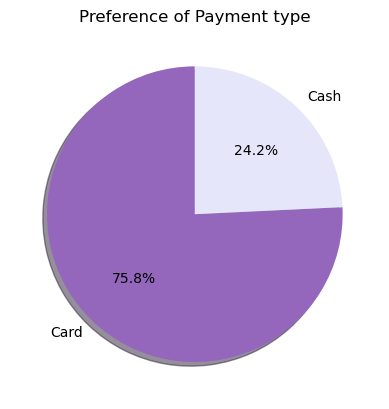

In [48]:
plt.title('Preference of Payment type')
plt.pie(taxi_data['payment_type'].value_counts(normalize=True), labels=taxi_data['payment_type'].value_counts().index,
       startangle=90,shadow=True,autopct='%1.1f%%', colors=['#9467bd','#e6e6fa'])
plt.show()

In [52]:
# calculating the total passenger count distribution based on the different payment type
passenger_count=taxi_data.groupby(['payment_type','passenger_count']).size().reset_index(name='count')
passenger_count

,payment_type,passenger_count,count
0,Card,1,3310008
1,Card,2,1057608
2,Card,3,378754
3,Card,4,242058
4,Card,5,147816
5,Cash,1,1054189
6,Cash,2,343311
7,Cash,3,118398
8,Cash,4,93921
9,Cash,5,33636


In [54]:
#What percentage of total trips were taken by each passenger group under each payment type?
passenger_count['Percentage']=(passenger_count['count']/passenger_count['count'].sum())*100
passenger_count

,payment_type,passenger_count,count,Percentage
0,Card,1,3310008,48.822344
1,Card,2,1057608,15.599631
2,Card,3,378754,5.586590
3,Card,4,242058,3.570335
4,Card,5,147816,2.180274
5,Cash,1,1054189,15.549201
6,Cash,2,343311,5.063809
7,Cash,3,118398,1.746361
8,Cash,4,93921,1.385327
9,Cash,5,33636,0.496128


In [55]:
48.822344+15.599631+5.586590+3.570335+2.180274

75.759174

In [56]:
#We will create custom transformed dataframe to plot stacked barchart
#Creates a new DataFrame with:Column payment_type as string and Columns 1 to 5 for passenger counts
df=pd.DataFrame(columns=['payment_type',1,2,3,4,5])
df['payment_type']=['Card','Cash']
df

,payment_type,1,2,3,4,5
0,Card,NaN,NaN,NaN,NaN,NaN
1,Cash,NaN,NaN,NaN,NaN,NaN


In [57]:
#df.iloc[0,1:] → targets the first row (0) and columns 1 to the end (i.e., for passenger counts 1 to 5)
#passenger_count.iloc[:5, -1]: :5 → selects the first 5 rows (assuming they belong to 'Card')
#-1 → selects the last column (which is 'count')
df.iloc[0,1:]= passenger_count.iloc[:5,-1]
df.iloc[1,1:]= passenger_count.iloc[5:,-1]
df

,payment_type,1,2,3,4,5
0,Card,48.822344,15.599631,5.58659,3.570335,2.180274
1,Cash,15.549201,5.063809,1.746361,1.385327,0.496128


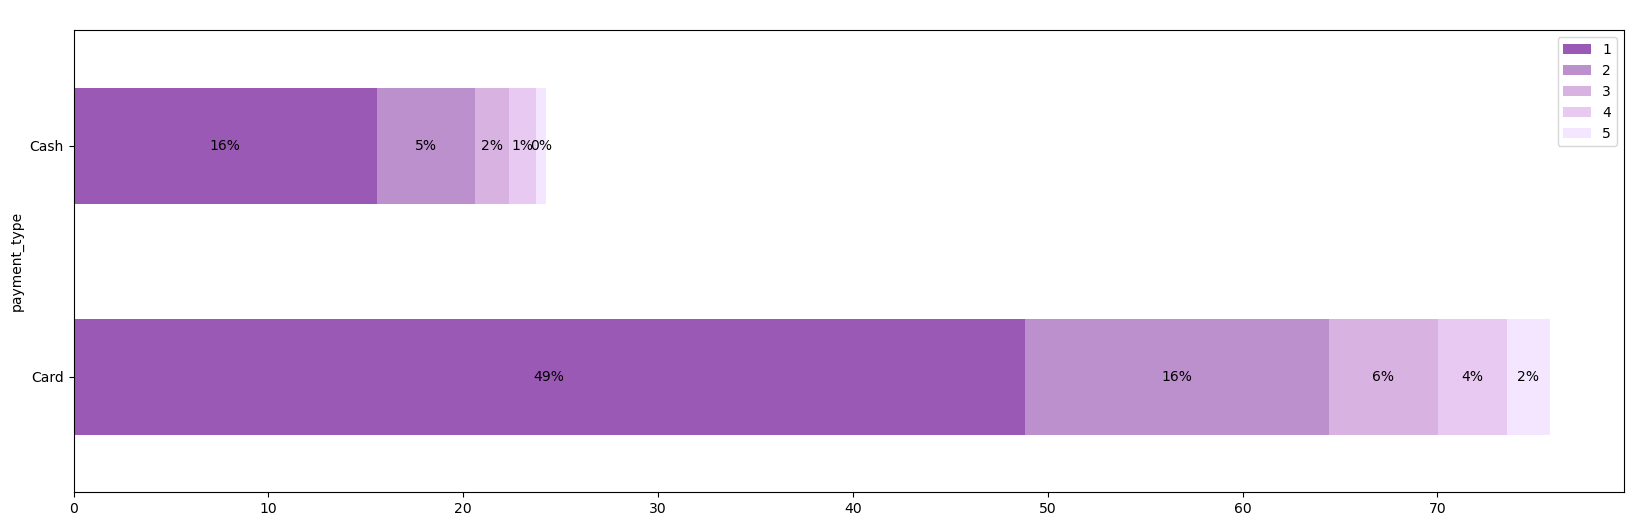

In [75]:
#plt.subplots() creates a figure and an axes object.Axes object is where the actual plot lives,The individual plot area — where the chart is drawn.
fig, ax = plt.subplots(figsize=(20, 6))
#x='payment_type': Sets the column for the Y-axis (horizontal bar).
#kind='barh': Means horizontal bar chart.
#stacked=True: Stacks the bars (each stack represents passenger counts 1 to 5).
#ax=ax: Plots on the ax object created earlier.
#color=[...]: Uses a custom palette 
df.plot(x='payment_type', kind='barh', stacked=True, title=' ', ax=ax, color = ['#9b59b6', '#bc8fcd', '#d8b2e1', '#e8c9f1', '#f5e6ff'] )

# Add percentage text
#Loops through each bar segment (rectangle) in the stacked chart.
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}%'.format(width),
            horizontalalignment='center',
            verticalalignment='center')

# Hypothesis Testing

Quantile-quantile (QQ) plots can be used to assess whether the fare amount distributions for each payment type are approximately normally distributed. If the data points closely align with the diagonal line in the plot, it suggests that the data follows a normal distribution.

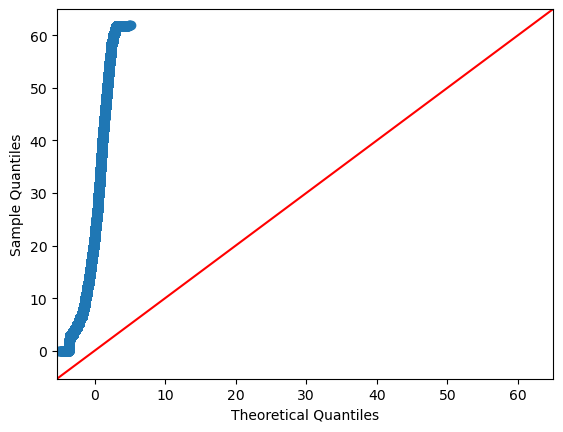

In [79]:
#create Q-Q plot with 45-degree line added to plot
fig=sm.qqplot(taxi_data['fare_amount'],line='45')
plt.show()

Since blue line is not overlapping with the red diagonal line, it means that the data is not normally distributed.
Previously plotted histogram also shows skewness at right side and no normal distribution. Hence we cant use Z test.

We will use a t-test because:
1) We don’t know σ population standard deviation (which is almost always true in real-world problems)
2) We are comparing the means of two independent groups (like Card vs Cash users)
3) We want to check if the difference in means is statistically significant

**Null Hypothesis (H₀):** There is no significant difference in the average fare between customers who pay by card and those who pay by cash.

**Alternative Hypothesis (H₁):** There is a significant difference in the average fare between customers who pay by card and those who pay by cash.


In [80]:
#Create sample 1
card_fare=taxi_data[taxi_data['payment_type']=='Card']['fare_amount']

#Create sample 2
cash_fare=taxi_data[taxi_data['payment_type']=='Cash']['fare_amount']

In [82]:
# performing t test on both the different sample
t_stat,p_value= st.ttest_ind(a=card_fare, b=cash_fare, equal_var=False)
print(f"T-statistic : {t_stat}, P- value : {p_value}")

T-statistic : 439.1739926017671, P- value : 0.0


In [84]:
# comparing the p value with the significance of 5% or 0.05
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in average fare between Card and Cash users.")
else:
    print("Fail to reject the null hypothesis: No significant difference in average fare between Card and Cash users.")

Reject the null hypothesis: There is a significant difference in average fare between Card and Cash users.


Since p value is significantly smaller than the significance level of 5%, we will reject the null hypothesis.

You conclude that there is a statistically significant difference in the average fare amount between customers who use credit cards and customers who use cash.

**Business Insight**

Customers who pay by Card tend to have higher average fares compared to those who pay by Cash. This could indicate that Card users take longer or more expensive trips. Therefore, encouraging Card payments — for example, through app promotions, discounts, or in-vehicle prompts — could potentially increase driver earnings without negatively impacting customer experience.